<a href="https://colab.research.google.com/github/Panini783/machineLearn/blob/main/%D0%9B%D0%A05_%D0%A1%D0%BB%D1%8E%D1%81%D0%B0%D1%80_3_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Daily Weather Time Series Data - Delhi, India**

https://www.kaggle.com/datasets/yug201/daily-climate-time-series-data-delhi-india?select=kaggel_weather_2013_to_2024.csv

**Тема:** Прогнозування часових рядів на основі кліматичних даних

**Мета роботи:**
Навчитися виконувати аналіз часових рядів, проводити дослідницький аналіз даних (EDA), визначати автокореляційні залежності, будувати моделі прогнозування та оцінювати їхню точність.

**Вихідні дані**

Для виконання роботи використовується датасет Daily Climate Time Series Data (Delhi, India) з платформи Kaggle, який містить щоденні кліматичні показники (температура, вологість, опади тощо) за кілька років.


1. Завантажити датасет з Kaggle.

2. Імпортувати дані у середовище Python (Jupyter Notebook або Google Colab).

3. Ознайомитися зі структурою датасету (head(), info(), describe()).

4. Попередня обробка даних

-Перетворити колонку з датою у формат datetime.

-Відсортувати дані за датою.

-Встановити дату як індекс часового ряду.

-Перевірити наявність пропущених значень та за необхідності обробити їх.

5. Дослідницький аналіз даних (EDA)

-Побудувати графік зміни температури у часі.

-Побудувати ковзне середнє значення температури.

-Побудувати гістограму розподілу температури.

-Побудувати boxplot для виявлення можливих викидів.

-Аналіз автокореляції

Побудувати графік автокореляційної функції (ACF).

Побудувати графік часткової автокореляції (PACF).

-Проаналізувати залежність значень часового ряду від попередніх періодів.

6.Підготовка даних для моделювання

-Розділити дані на тренувальну та тестову вибірки (наприклад, 80% / 20%).

7. Побудувати щонайменше три моделі прогнозування:

-ARIMA (класична статистична модель);

-Prophet (модель прогнозування часових рядів від Meta);

-LSTM (нейронна мережа для послідовних даних).

8. Оцінка моделей
Для кожної моделі обчислити метрики:

-MAE (Mean Absolute Error)

-RMSE (Root Mean Squared Error)

-MAPE (Mean Absolute Percentage Error)

8.Візуалізація результатів

-Побудувати графіки прогнозованих та фактичних значень.

-Побудувати порівняльний графік прогнозів усіх моделей.

-Порівняння моделей

-Створити таблицю з метриками точності.

9.Визначити модель, яка показала найкращий результат.

In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import sktime
import seaborn
import datetime
import statsmodels

from prophet import Prophet

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [129]:
!kaggle datasets download -d yug201/daily-climate-time-series-data-delhi-india
!unzip daily-climate-time-series-data-delhi-india.zip

Dataset URL: https://www.kaggle.com/datasets/yug201/daily-climate-time-series-data-delhi-india
License(s): Attribution 4.0 International (CC BY 4.0)
daily-climate-time-series-data-delhi-india.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  daily-climate-time-series-data-delhi-india.zip
replace kaggel_weather_2013_to_2024.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: kaggel_weather_2013_to_2024.csv  


In [130]:
# Зчитайте датасет у DataFrame та перегляньте дані
df = pd.read_csv('kaggel_weather_2013_to_2024.csv')
print(df.head())

   Unnamed: 0       DATE  tempmax  tempmin  temp  feelslikemax  feelslikemin  \
0           0  4/14/2013     37.7     23.1  28.7          35.4          23.1   
1           1  4/15/2013     37.5     21.1  28.6          35.3          21.1   
2           2  4/16/2013     40.1     21.9  31.7          37.5          21.9   
3           3  4/17/2013     36.4     21.0  29.9          34.0          21.0   
4           4  4/18/2013     37.5     21.7  30.6          35.2          21.7   

   feelslike  humidity  precip  ...  year-2000  weekofyear  tempmax_humidity  \
0       28.1      39.7     2.0  ...         13          15           1496.69   
1       28.0      41.7     0.0  ...         13          16           1563.75   
2       30.4      30.7     0.0  ...         13          16           1231.07   
3       28.5      27.4     0.0  ...         13          16            997.36   
4       29.2      23.7     0.0  ...         13          16            888.75   

   tempmin_humidity temp_humidity  fee

Підготовка даних

In [131]:
# Виконайте попередню обробку даних:
# - DATE -> datetime
# - сортування за датою
# - видалення зайвих колонок
# - встановлення DATE як індексу
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE')
df = df.set_index('DATE')

In [132]:
# Перегляньте інформацію про структуру датасету
print(df.info())
print("\nСтатистичний опис:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3557 entries, 2013-04-14 to 2024-11-30
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             3557 non-null   int64  
 1   tempmax                3557 non-null   float64
 2   tempmin                3557 non-null   float64
 3   temp                   3557 non-null   float64
 4   feelslikemax           3557 non-null   float64
 5   feelslikemin           3557 non-null   float64
 6   feelslike              3557 non-null   float64
 7   humidity               3557 non-null   float64
 8   precip                 3557 non-null   float64
 9   precipprob             3557 non-null   int64  
 10  precipcover            3557 non-null   float64
 11  windspeed              3557 non-null   float64
 12  sealevelpressure       3557 non-null   float64
 13  conditions             3557 non-null   object 
 14  Year                   3557 non-null  

In [133]:
# Перевірте наявність пропущених значень
print("Пропущені значення:")
print(df.isnull().sum())

Пропущені значення:
Unnamed: 0               0
tempmax                  0
tempmin                  0
temp                     0
feelslikemax             0
feelslikemin             0
feelslike                0
humidity                 0
precip                   0
precipprob               0
precipcover              0
windspeed                0
sealevelpressure         0
conditions               0
Year                     0
month                    0
dayofweek                0
dayofyear                0
year-2000                0
weekofyear               0
tempmax_humidity         0
tempmin_humidity         0
temp_humidity            0
feelslikemax_humidity    0
feelslikemin_humidity    0
feelslike_humidity       0
temp_range               0
heat_index               0
dtype: int64


Графік температури

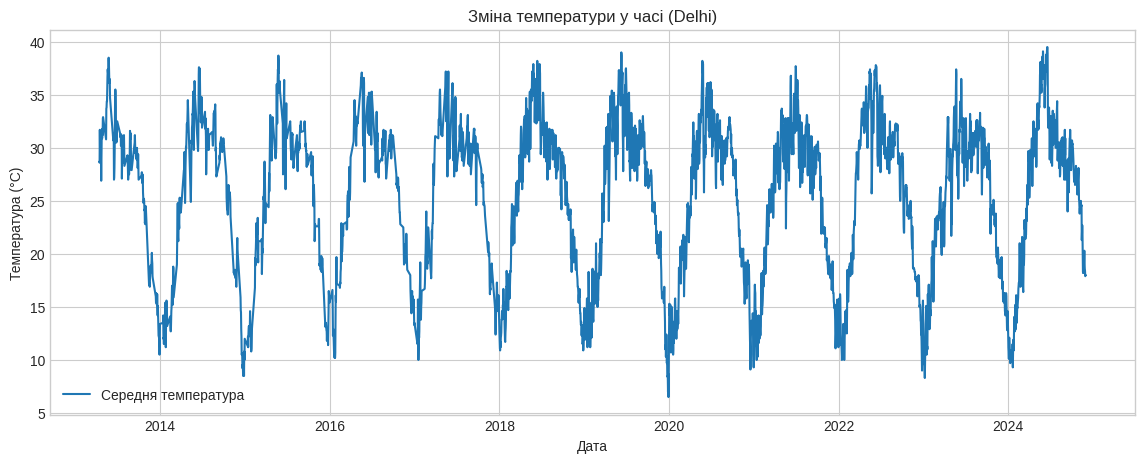

In [134]:
# Побудуйте графік зміни температури у часі
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['temp'], color='tab:blue', label='Середня температура')
plt.title('Зміна температури у часі (Delhi)')
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.legend()
plt.show()

Ковзне середнє

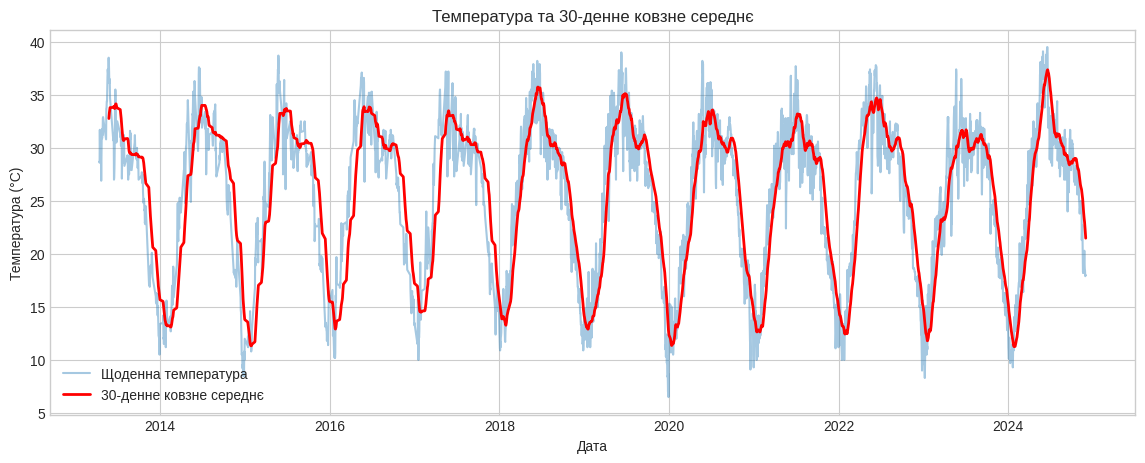

In [135]:
# Обчисліть та візуалізуйте ковзне середнє температури
df['rolling_30_temp'] = df['temp'].rolling(window=30).mean()

plt.figure(figsize=(14, 5))
plt.plot(df.index, df['temp'], alpha=0.4, label='Щоденна температура')
plt.plot(df.index, df['rolling_30_temp'], color='red', linewidth=2, label='30-денне ковзне середнє')
plt.title('Температура та 30-денне ковзне середнє')
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.legend()
plt.show()

Розподіл температури

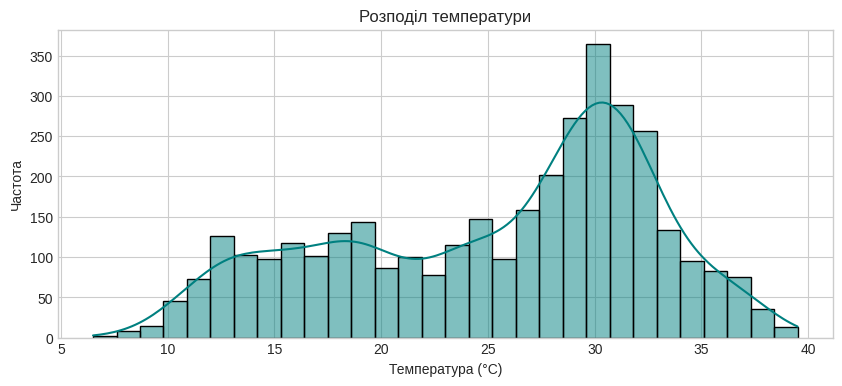

In [136]:
# Побудуйте гістограму розподілу температури
plt.figure(figsize=(10, 4))
sns.histplot(df['temp'], kde=True, bins=30, color='teal')
plt.title('Розподіл температури')
plt.xlabel('Температура (°C)')
plt.ylabel('Частота')
plt.show()

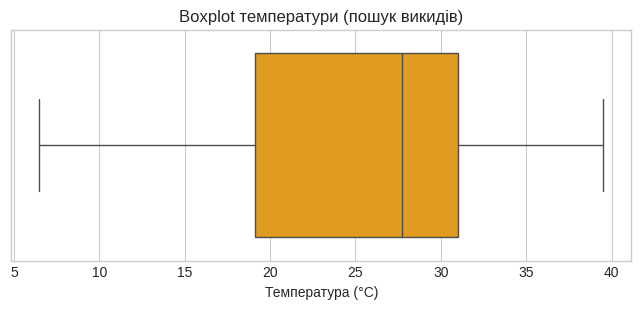

In [137]:
# Побудуйте boxplot температури для аналізу викидів
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['temp'], color='orange')
plt.title('Boxplot температури (пошук викидів)')
plt.xlabel('Температура (°C)')
plt.show()

Аналіз автокореляції
ACF

PACF

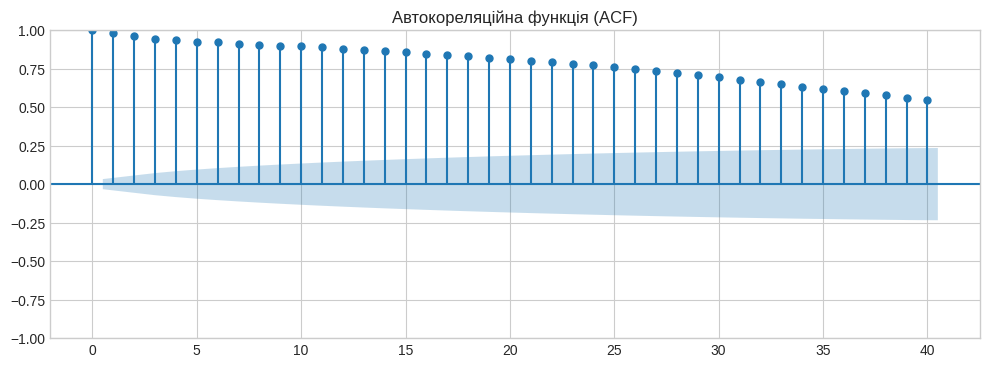

In [138]:
# Побудуйте графік автокореляційної функції (ACF)
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(df['temp'].dropna(), lags=40, ax=ax)
plt.title('Автокореляційна функція (ACF)')
plt.show()

Автокореляційна функція (ACF) використовується для аналізу залежності значень часового ряду від його попередніх значень. Вона відображає ступінь кореляції між значенням показника у певний момент часу та значеннями цього самого показника у попередні моменти часу, які називаються лагами. Побудова графіка автокореляційної функції дозволяє виявити, чи існує статистично значуща залежність між поточним значенням ряду та його попередніми спостереженнями. На такому графіку по горизонтальній осі відкладаються лаги, тобто кількість часових кроків назад, а по вертикальній — значення коефіцієнта автокореляції. Аналіз графіка ACF дає можливість виявити наявність тренду, сезонності або інших закономірностей у часовому ряді, а також використовується для визначення параметрів статистичних моделей прогнозування, зокрема моделі ARIMA.

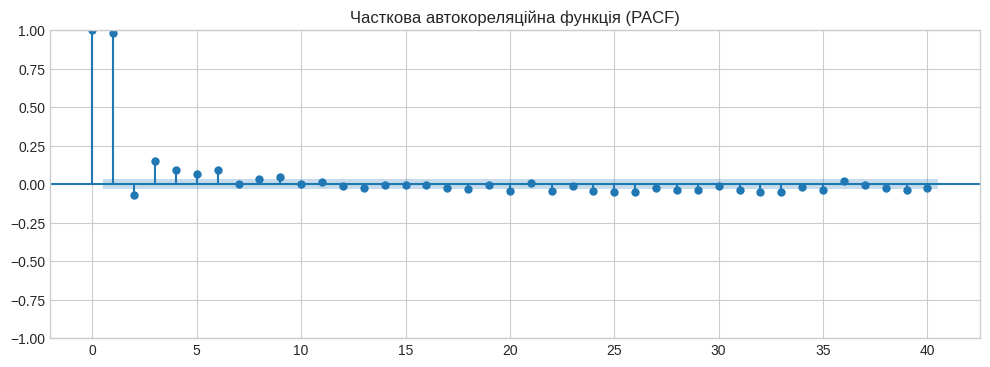

In [139]:
# Побудуйте графік часткової автокореляційної функції (PACF)
fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(df['temp'].dropna(), lags=40, ax=ax)
plt.title('Часткова автокореляційна функція (PACF)')
plt.show()

Часткова автокореляційна функція (PACF) застосовується для більш точного визначення залежності між значеннями часового ряду. На відміну від звичайної автокореляційної функції, PACF вимірює кореляцію між значенням ряду у певний момент часу та значенням у попередній момент часу з конкретним лагом, усуваючи вплив усіх проміжних лагів. Таким чином, часткова автокореляція показує «чисту» залежність між двома спостереженнями часового ряду. Побудова графіка PACF дозволяє визначити, які саме лаги мають статистично значущий вплив на значення ряду. Це є важливим етапом під час побудови моделей прогнозування часових рядів, оскільки аналіз графіка часткової автокореляції використовується для визначення порядку авторегресійної складової моделі, зокрема параметра
𝑝
p у моделі ARIMA.

In [140]:
# Сформуйте цільовий часовий ряд та розділіть його на train/test у часовому порядку

series = df['temp']

train_size = int(len(series) * 0.8)
train, test = series.iloc[:train_size], series.iloc[train_size:]

print(f"Тренувальна вибірка: {len(train)} записів")
print(f"Тестова вибірка: {len(test)} записів")

# Функція для обчислення MAPE
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

Тренувальна вибірка: 2845 записів
Тестова вибірка: 712 записів


ARIMA

https://developer.ibm.com/tutorials/awb-arima-models-in-python/

In [141]:
# Побудуйте та навчіть модель ARIMA. Отримайте прогноз для тестової вибірки
train_arima = train.reset_index(drop=True)

arima_model = ARIMA(train_arima, order=(5, 1, 2))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))
arima_forecast.index = test.index

print(arima_forecast.head())

DATE
2022-12-20    14.895737
2022-12-21    15.071189
2022-12-22    15.161451
2022-12-23    15.179429
2022-12-24    15.200756
Name: predicted_mean, dtype: float64


In [142]:
# Виведіть статистичний звіт навченої ARIMA-моделі
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   temp   No. Observations:                 2845
Model:                 ARIMA(5, 1, 2)   Log Likelihood               -4969.050
Date:                Fri, 09 Oct 2026   AIC                           9954.101
Time:                        11:14:36   BIC                          10001.724
Sample:                             0   HQIC                          9971.277
                               - 2845                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1810      0.227      0.799      0.424      -0.263       0.625
ar.L2          0.1094      0.205      0.533      0.594      -0.293       0.511
ar.L3         -0.1108      0.049     -2.242      0.0

сигма 2 : це представляє дисперсію залишкових значень, чим менше, тим краще

логарифмічна правдоподібність : це оцінка максимальної правдоподібності для моделі ARIMA, чим вище, тим краще

aic : міра ступеню відповідності та економності моделі, чим нижче, тим краще

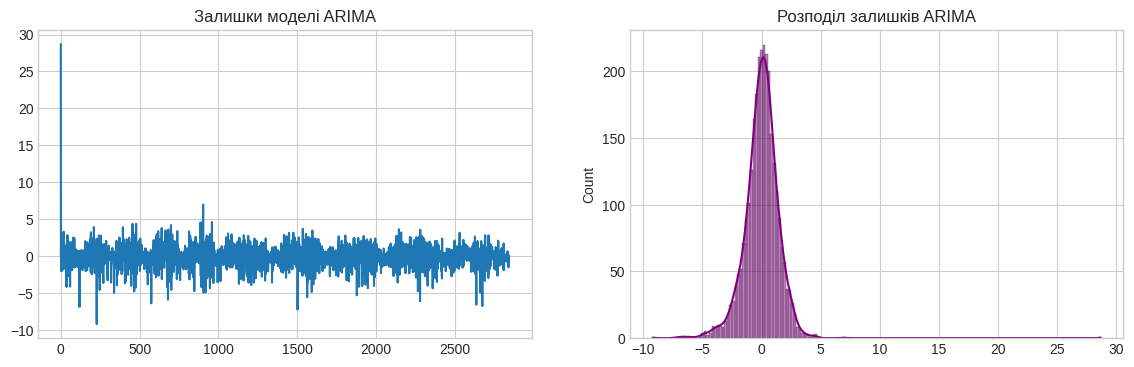

In [143]:
# Проаналізуйте залишки ARIMA-моделі та побудуйте відповідні графіки
residuals = arima_fit.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(residuals)
axes[0].set_title('Залишки моделі ARIMA')

sns.histplot(residuals, kde=True, ax=axes[1], color='purple')
axes[1].set_title('Розподіл залишків ARIMA')
plt.show()

In [144]:
# Реалізуйте MAPE та обчисліть MAE, RMSE, MAPE для ARIMA
arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
arima_mape = calculate_mape(test.values, arima_forecast.values)

print(f"ARIMA — MAE: {arima_mae:.4f}, RMSE: {arima_rmse:.4f}, MAPE: {arima_mape:.2f}%")

ARIMA — MAE: 10.9278, RMSE: 12.5009, MAPE: 39.59%


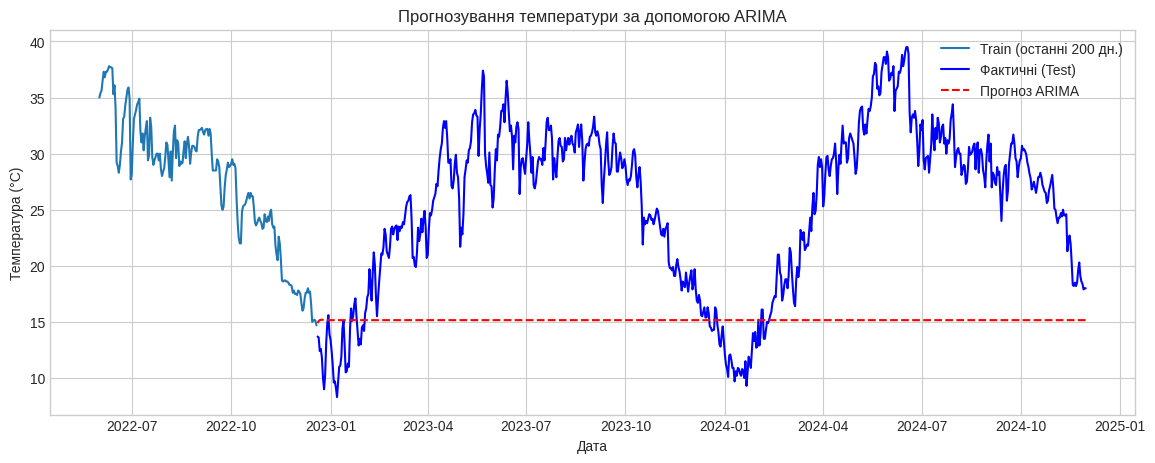

In [145]:
# Візуалізуйте фактичні значення та прогноз ARIMA
plt.figure(figsize=(14, 5))
plt.plot(train.index[-200:], train.values[-200:], label='Train (останні 200 дн.)')
plt.plot(test.index, test.values, label='Фактичні (Test)', color='blue')
plt.plot(test.index, arima_forecast, label='Прогноз ARIMA', color='red', linestyle='--')
plt.title('Прогнозування температури за допомогою ARIMA')
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.legend()
plt.show()

PROPHET

https://facebook.github.io/prophet/docs/quick_start.html

In [146]:
# Підготуйте дані у форматі, необхідному для Prophet

prophet_train = train.reset_index().rename(columns={'DATE': 'ds', 'temp': 'y'})
prophet_test = test.reset_index().rename(columns={'DATE': 'ds', 'temp': 'y'})

In [147]:
# Створіть та навчіть модель Prophet
prophet_model = Prophet(yearly_seasonality=True, daily_seasonality=False)
prophet_model.fit(prophet_train)

Прогноз

In [148]:
# Побудуйте прогноз Prophet для тестового періоду
future = prophet_test[['ds']].copy()
prophet_forecast_df = prophet_model.predict(future)
prophet_forecast = prophet_forecast_df['yhat'].values

In [149]:
# Обчисліть MAE, RMSE, MAPE для Prophet
prophet_mae = mean_absolute_error(test, prophet_forecast)
prophet_rmse = np.sqrt(mean_squared_error(test, prophet_forecast))
prophet_mape = calculate_mape(test.values, prophet_forecast)

print(f"Prophet — MAE: {prophet_mae:.4f}, RMSE: {prophet_rmse:.4f}, MAPE: {prophet_mape:.2f}%")

Prophet — MAE: 2.0047, RMSE: 2.5902, MAPE: 9.03%


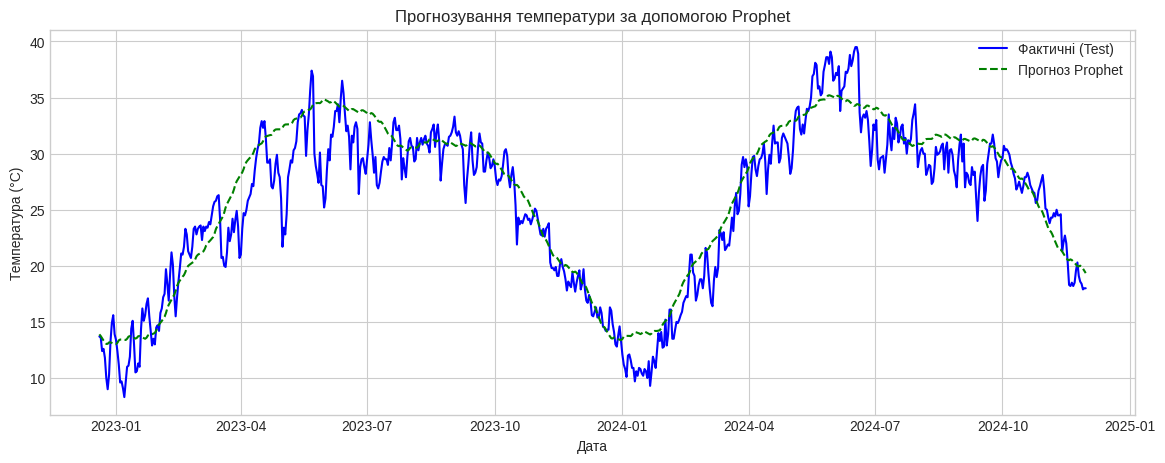

In [150]:
# Візуалізуйте фактичні значення та прогноз Prophet
plt.figure(figsize=(14, 5))
plt.plot(test.index, test.values, label='Фактичні (Test)', color='blue')
plt.plot(test.index, prophet_forecast, label='Прогноз Prophet', color='green', linestyle='--')
plt.title('Прогнозування температури за допомогою Prophet')
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.legend()
plt.show()

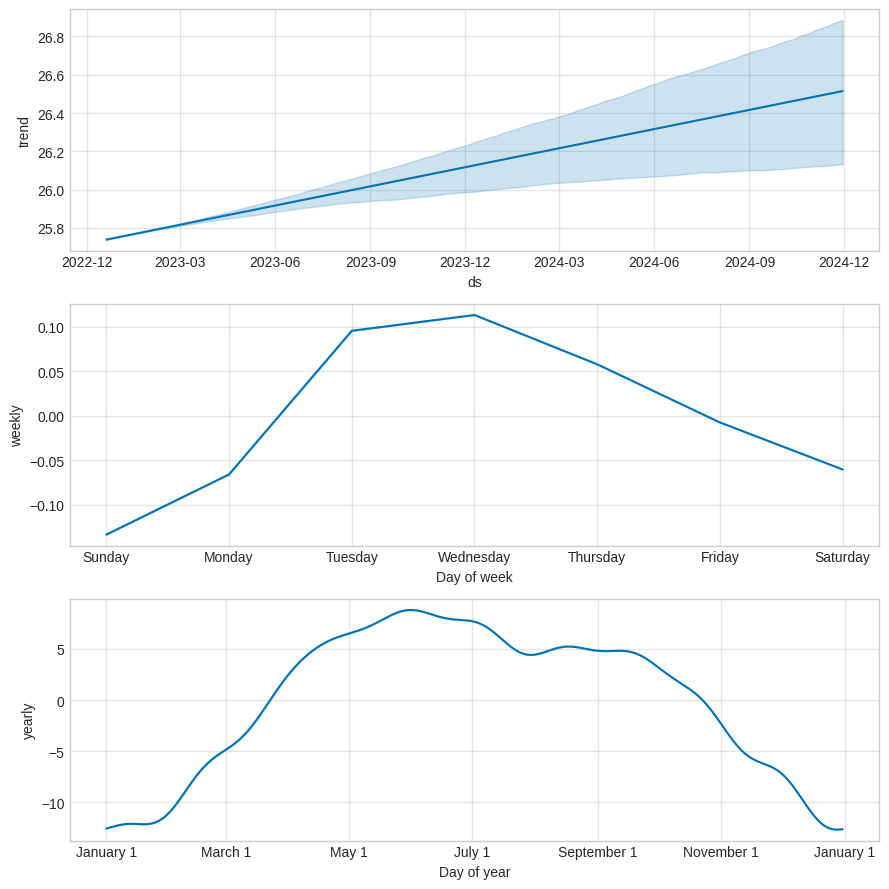

In [151]:
# Побудуйте компоненти моделі Prophet
fig_comp = prophet_model.plot_components(prophet_forecast_df)
plt.show()

ПІДГОТОВКА ДАНИХ ДЛЯ LSTM

In [152]:
# Масштабуйте часовий ряд та сформуйте послідовності для LSTM
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(series.values.reshape(-1, 1))

def create_sequences(data, time_steps=30):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i : i + time_steps])
        y.append(data[i + time_steps])
    return np.array(X), np.array(y)

TIME_STEPS = 30
X, y = create_sequences(scaled_data, TIME_STEPS)

In [153]:
# Розділіть послідовності на тренувальну та тестову вибірки без перемішування
train_split = int(len(X) * 0.8)

X_train, X_test = X[:train_split], X[train_split:]
y_train, y_test = y[:train_split], y[train_split:]

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (2821, 30, 1), X_test shape: (706, 30, 1)


In [154]:
# Побудуйте архітектуру LSTM-моделі та скомпілюйте її
lstm_model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(X_train.shape[1], 1)),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [155]:
# Навчіть LSTM-модель
history = lstm_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0232 - val_loss: 0.0043
Epoch 2/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0048 - val_loss: 0.0039
Epoch 3/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0045 - val_loss: 0.0036
Epoch 4/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0042 - val_loss: 0.0035
Epoch 5/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0040 - val_loss: 0.0033
Epoch 6/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0039 - val_loss: 0.0038
Epoch 7/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0038 - val_loss: 0.0032
Epoch 8/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0035 - val_loss: 0.0029
Epoch 9/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0034 - val_loss: 0.0027
Epoch 10/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0033 - val_loss: 0.0037
Epoch 11/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0032 - val_loss: 0.0026
Epoch 12/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0

In [156]:
# Виведіть структуру LSTM-моделі
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,885 (198.77 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 33,924 (132.52 KB)

In [157]:
# Отримайте прогноз LSTM та виконайте зворотне масштабування
lstm_predictions_scaled = lstm_model.predict(X_test)

# Зворотне перетворення
lstm_forecast = scaler.inverse_transform(lstm_predictions_scaled).flatten()
y_test_actual = scaler.inverse_transform(y_test).flatten()

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [158]:
# Сформуйте часові мітки для тестового прогнозу LSTM
lstm_test_index = series.index[train_split + TIME_STEPS:]

In [159]:
# Обчисліть MAE, RMSE, MAPE для LSTM
lstm_mae = mean_absolute_error(y_test_actual, lstm_forecast)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_forecast))
lstm_mape = calculate_mape(y_test_actual, lstm_forecast)

print(f"LSTM — MAE: {lstm_mae:.4f}, RMSE: {lstm_rmse:.4f}, MAPE: {lstm_mape:.2f}%")

LSTM — MAE: 1.0479, RMSE: 1.3655, MAPE: 4.61%


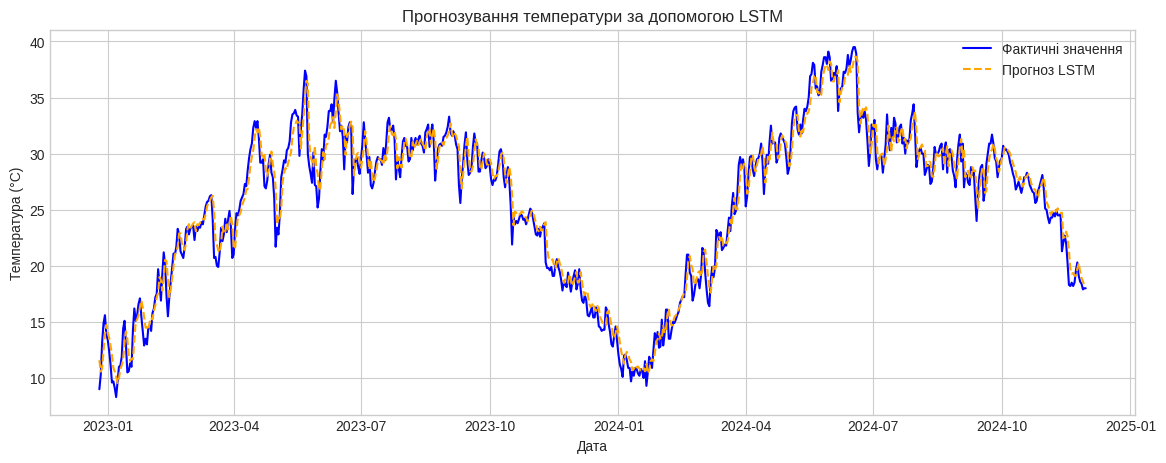

In [160]:
# Візуалізуйте фактичні значення та прогноз LSTM
plt.figure(figsize=(14, 5))
plt.plot(lstm_test_index, y_test_actual, label='Фактичні значення', color='blue')
plt.plot(lstm_test_index, lstm_forecast, label='Прогноз LSTM', color='orange', linestyle='--')
plt.title('Прогнозування температури за допомогою LSTM')
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.legend()
plt.show()

Порівняння моделей

=== ПОРІВНЯННЯ МОДЕЛЕЙ ===
    Модель      MAE     RMSE  MAPE (%)
0    ARIMA  10.9278  12.5009   39.5920
1  Prophet   2.0047   2.5902    9.0279
2     LSTM   1.0479   1.3655    4.6122


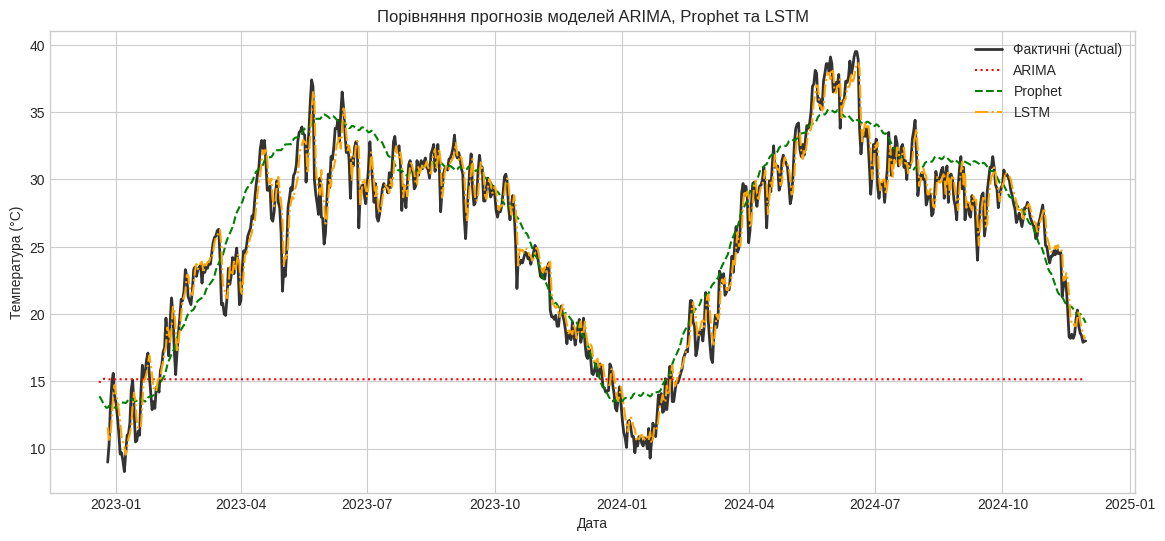

In [161]:
# Створіть підсумкову таблицю MAE, RMSE, MAPE для ARIMA, Prophet та LSTM
# Порівняйте моделі за отриманими результатами
results_df = pd.DataFrame({
    'Модель': ['ARIMA', 'Prophet', 'LSTM'],
    'MAE': [arima_mae, prophet_mae, lstm_mae],
    'RMSE': [arima_rmse, prophet_rmse, lstm_rmse],
    'MAPE (%)': [arima_mape, prophet_mape, lstm_mape]
})

print("=== ПОРІВНЯННЯ МОДЕЛЕЙ ===")
print(results_df.round(4))

# Порівняльний графік усіх прогнозів
plt.figure(figsize=(14, 6))
plt.plot(lstm_test_index, y_test_actual, label='Фактичні (Actual)', color='black', alpha=0.8, linewidth=2)
plt.plot(test.index, arima_forecast, label='ARIMA', color='red', linestyle=':')
plt.plot(test.index, prophet_forecast, label='Prophet', color='green', linestyle='--')
plt.plot(lstm_test_index, lstm_forecast, label='LSTM', color='orange', linestyle='-.')
plt.title('Порівняння прогнозів моделей ARIMA, Prophet та LSTM')
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.legend()
plt.show()

## Висновок

Сформулюйте висновок за результатами роботи: коротко охарактеризуйте виконаний аналіз, порівняйте моделі ARIMA, Prophet та LSTM за метриками MAE, RMSE і MAPE та зазначте, яка модель продемонструвала найкращу якість прогнозування.
